# Exploração inicial do dataset de energia

Este notebook apresenta uma exploração inicial do dataset de consumo energético fornecido pela Câmara Municipal da Maia.

Objetivos desta exploração:

- compreender a estrutura dos dados
- identificar variáveis relevantes
- avaliar qualidade e cobertura temporal
- preparar os dados para futuras análises de padrões e deteção de anomalias

In [36]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [37]:
data_raw_path = "../data_raw"
os.listdir(data_raw_path)

['aqualog.zip',
 'aqualog_11_2025.csv.zip',
 'Consumo15m.zip',
 'consumo15m_11_2025.csv.zip',
 'electricityloaddiagrams20112014.zip',
 'meteo_11_2025.csv.zip',
 'stcp.zip']

In [38]:
zip_path = "../data_raw/consumo15m_11_2025.csv.zip"

In [39]:
with zipfile.ZipFile(zip_path) as z:
    print(z.namelist())

['consumo15m_11_2025.csv']


In [40]:
with zipfile.ZipFile(zip_path) as z:
    with z.open(z.namelist()[0]) as f:
        df_energia = pd.read_csv(f)

In [41]:
df_energia.head()

,CPE,tstamp,DadosdeConsumo,PotActiva,PotReactIndut,PotReactCapac
0,PT0002000089069203YG,2022-12-31 00:15:00,NaN,0.296,NaN,NaN
1,PT0002000089069203YG,2022-12-31 00:30:00,NaN,0.292,NaN,NaN
2,PT0002000089069203YG,2022-12-31 00:45:00,NaN,0.284,NaN,NaN
3,PT0002000089069203YG,2022-12-31 01:00:00,NaN,0.280,NaN,NaN
4,PT0002000089069203YG,2022-12-31 01:15:00,NaN,0.272,NaN,NaN


In [42]:
df_energia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5940182 entries, 0 to 5940181
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   CPE             object 
 1   tstamp          object 
 2   DadosdeConsumo  float64
 3   PotActiva       float64
 4   PotReactIndut   float64
 5   PotReactCapac   float64
dtypes: float64(4), object(2)
memory usage: 271.9+ MB


In [43]:
df_energia.shape

(5940182, 6)

In [44]:
df_energia["tstamp"] = pd.to_datetime(df_energia["tstamp"])

In [45]:
df_energia = df_energia.sort_values("tstamp")

In [46]:
print("Início:", df_energia["tstamp"].min())
print("Fim:", df_energia["tstamp"].max())

Início: 2022-12-31 00:15:00
Fim: 2025-05-01 00:00:00


In [47]:
df_energia["CPE"].nunique()

91

In [48]:
df_energia.isna().sum()

CPE                     0
tstamp                  0
DadosdeConsumo    5940182
PotActiva               0
PotReactIndut     2271472
PotReactCapac     2271472
dtype: int64

### Observações iniciais

A análise de valores em falta mostra que:

- A variável **DadosdeConsumo** encontra-se praticamente vazia.
- A variável **PotActiva** apresenta cobertura completa.
- As variáveis **PotReactIndut** e **PotReactCapac** apresentam vários valores em falta.

Assim, **PotActiva será considerada a variável principal para análise inicial**.

### Visualização exploratória global

O gráfico seguinte mostra todas as medições de PotActiva ao longo do tempo.

Como mistura medições de todos os CPE, serve apenas para perceber a escala geral dos dados e a densidade temporal, não sendo adequado para análise detalhada.

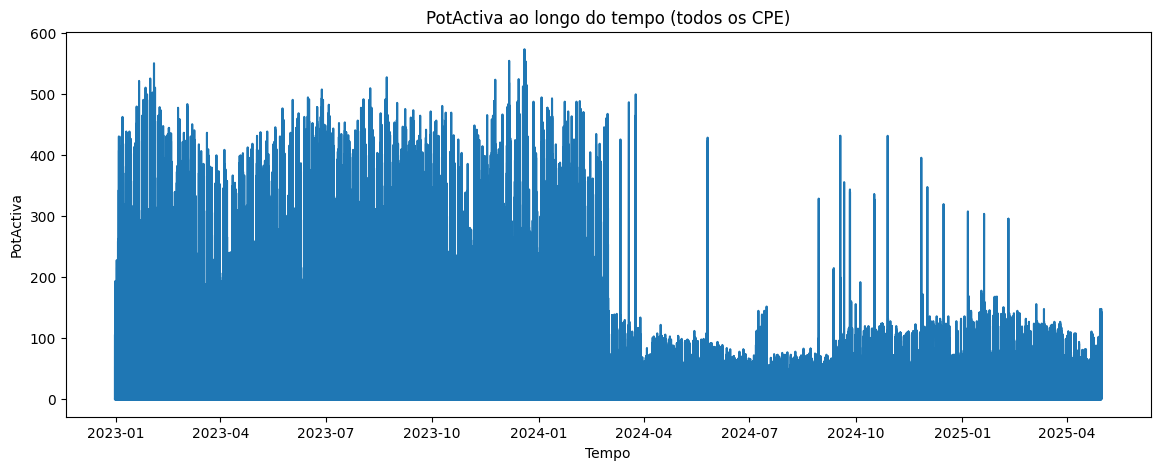

In [49]:
plt.figure(figsize=(14,5))

plt.plot(df_energia["tstamp"], df_energia["PotActiva"])

plt.title("PotActiva ao longo do tempo (todos os CPE)")
plt.xlabel("Tempo")
plt.ylabel("PotActiva")

plt.show()

In [50]:
df_pivot = df_energia.pivot_table(
    index="tstamp",
    columns="CPE",
    values="PotActiva"
)

df_pivot.head()

CPE,PT0002000032936306KX,PT0002000032942455NH,PT0002000032959511HP,PT0002000032966446CC,PT0002000032968749YT,PT0002000032969229AC,PT0002000032976997LZ,PT0002000032990792KD,PT0002000032993611ME,PT0002000033016394FN,...,PT0002000119303492KB,PT0002000120237616VJ,PT0002000120320157HF,PT0002000123648159KR,PT0002000123801456QA,PT0002000125379984SH,PT0002000131605602FL,PT0002000133505542CK,PT0002000133685986TF,PT0002000201936109ME
tstamp,,,,,,,,,,,,,,,,,,,,,
2022-12-31 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,3.0,NaN,12.0,NaN,1.0,NaN,NaN,NaN,NaN
2022-12-31 00:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,3.0,NaN,13.0,NaN,1.0,NaN,NaN,NaN,NaN
2022-12-31 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,3.0,NaN,17.0,NaN,0.0,NaN,NaN,NaN,NaN
2022-12-31 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,2.0,NaN,16.0,NaN,1.0,NaN,NaN,NaN,NaN
2022-12-31 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,3.0,NaN,16.0,NaN,1.0,NaN,NaN,NaN,NaN


In [51]:
df_pivot.shape

(81777, 91)

In [52]:
missing_pct = df_pivot.isna().mean() * 100

missing_pct.sort_values().head(10)

CPE
PT0002000078233981HJ    0.015897
PT0002000068859393XH    0.015897
PT0002000033074862LZ    0.015897
PT0002000100113293JT    0.015897
PT0002000115031201VQ    0.015897
PT0002000105483259QH    0.017120
PT0002000068859187RL    0.017120
PT0002000068856906VS    0.018343
PT0002000068856781NM    0.018343
PT0002000073231742VK    0.018343
dtype: float64

In [53]:
cpe_melhor = missing_pct.sort_values().index[0]

cpe_melhor

'PT0002000078233981HJ'

In [54]:
serie_melhor = df_pivot[cpe_melhor]

serie_melhor.head()

tstamp
2022-12-31 00:15:00    0.0
2022-12-31 00:30:00    1.0
2022-12-31 00:45:00    1.0
2022-12-31 01:00:00    0.0
2022-12-31 01:15:00    1.0
Name: PT0002000078233981HJ, dtype: float64

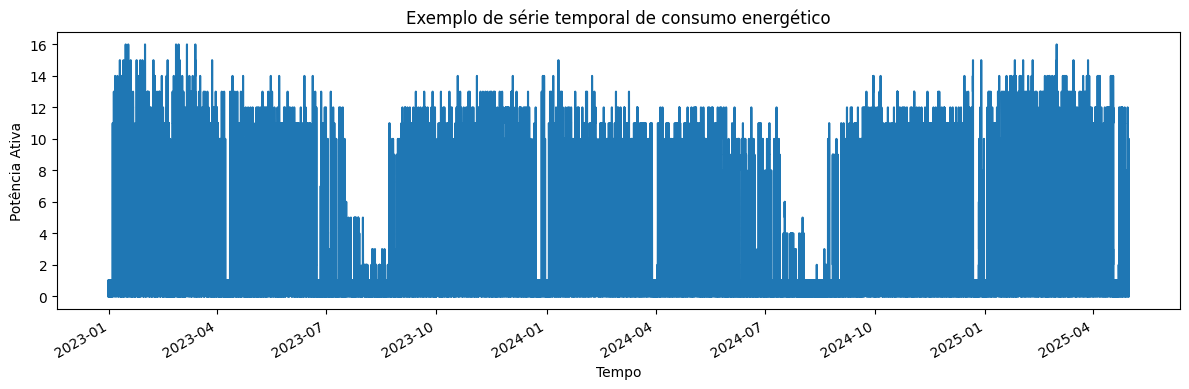

In [55]:
plt.figure(figsize=(12,4))

serie_melhor.plot()

plt.title("Exemplo de série temporal de consumo energético")
plt.xlabel("Tempo")
plt.ylabel("Potência Ativa")

plt.tight_layout()

plt.show()

In [56]:
df_pivot.index.to_series().diff().value_counts().head()

tstamp
0 days 00:15:00    81770
0 days 01:15:00        3
0 days 00:30:00        3
Name: count, dtype: int64

## Conclusões iniciais sobre o dataset de energia

- O dataset contém aproximadamente **5.9 milhões de registos** e **91 CPE distintos**, correspondendo a 91 séries temporais.
- O período temporal coberto vai de **31 de dezembro de 2022 a 1 de maio de 2025**.
- A coluna temporal `tstamp` foi convertida para formato datetime e os dados foram ordenados cronologicamente.
- A variável **DadosdeConsumo** encontra-se praticamente vazia e não será utilizada nesta fase.
- A variável **PotActiva** apresenta cobertura completa e será utilizada como variável principal.
- A frequência temporal dominante é de **15 minutos**, embora existam algumas irregularidades.
- A tabela pivotada permite representar o dataset como uma matriz temporal (timestamps × CPE).
- Para visualização foi selecionado um CPE com menor percentagem de valores em falta, permitindo observar uma série temporal mais representativa.